In [1]:
import glob
import random

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


In [2]:
TARGET_COL = "Jc"
FEATURE_COLS = ["T", "B", "theta"]

DATA_GLOB = "data/*.csv"
OUTPUT_CSV = "mlp_predictions.csv"

TEST_SIZE = 0.2
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 200
LR = 1e-3
HIDDEN_DIMS = [64, 64]

USE_LOG_TARGET = True
USE_TRIG_FEATURES = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int]):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [5]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if USE_TRIG_FEATURES and "theta" in df.columns:
        df["sin_theta"] = np.sin(df["theta"])
        df["cos_theta"] = np.cos(df["theta"])

    return df

In [20]:
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_data(data_glob: str = DATA_GLOB):
    files = sorted(glob.glob(data_glob))
    if not files:
        raise FileNotFoundError(f"No CSV files found for pattern: {data_glob}")

    df_list = [pd.read_csv(file_path) for file_path in files]
    df = pd.concat(df_list, ignore_index=True)
    df = df.rename(
        columns={
            "Temperature (K)": "T",
            "Applied field (T)": "B",
            "Applied field angle (°)": "theta",
            "Critical current (A)": "Jc",
        }
    )

    required_cols = FEATURE_COLS + [TARGET_COL]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    df = df.dropna(subset=required_cols)
    df = build_features(df)

    feature_cols = FEATURE_COLS.copy()
    if USE_TRIG_FEATURES and "theta" in FEATURE_COLS:
        feature_cols = [col for col in feature_cols if col != "theta"]
        feature_cols += ["sin_theta", "cos_theta"]

    X = df[feature_cols].to_numpy()
    y = df[TARGET_COL].to_numpy()

    if USE_LOG_TARGET:
        if np.any(y <= 0):
            raise ValueError("Jc must be positive when USE_LOG_TARGET=True.")
        y = np.log(y)

    return X, y, feature_cols


def evaluate(model, loader, device):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)
            preds.append(output.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    preds = np.vstack(preds).ravel()
    targets = np.vstack(targets).ravel()

    return preds, targets


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


In [21]:
def main():
    set_seed(RANDOM_STATE)

    X, y, used_feature_cols = load_data()
    print("Features:", used_feature_cols)
    print("Shape:", X.shape, y.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    train_dataset = TabularDataset(X_train, y_train)
    test_dataset = TabularDataset(X_test, y_test)

    use_pin_memory = DEVICE == "cuda"
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=use_pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=use_pin_memory,
    )

    model = MLPRegressor(input_dim=X_train.shape[1], hidden_dims=HIDDEN_DIMS).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        epoch_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:03d} | Train Loss: {epoch_loss:.6f}")

    pred_log, true_log = evaluate(model, test_loader, DEVICE)

    if USE_LOG_TARGET:
        pred = np.exp(pred_log)
        true = np.exp(true_log)
    else:
        pred = pred_log
        true = true_log

    r2 = r2_score(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))

    print(f"Test R2:   {r2:.6f}")
    print(f"Test RMSE: {rmse:.6f}")

    result_df = pd.DataFrame({"y_true": true, "y_pred": pred})
    result_df.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved: {OUTPUT_CSV}")


if __name__ == "__main__":
    main()


Features: ['T', 'B', 'sin_theta', 'cos_theta']
Shape: (8741, 4) (8741,)
Epoch 001 | Train Loss: 3.706004
Epoch 020 | Train Loss: 0.150037
Epoch 040 | Train Loss: 0.141807
Epoch 060 | Train Loss: 0.136027
Epoch 080 | Train Loss: 0.131626
Epoch 100 | Train Loss: 0.132034
Epoch 120 | Train Loss: 0.131280
Epoch 140 | Train Loss: 0.130219
Epoch 160 | Train Loss: 0.129735
Epoch 180 | Train Loss: 0.128985
Epoch 200 | Train Loss: 0.125330
Test R2:   0.961337
Test RMSE: 14.618772
Saved: mlp_predictions.csv


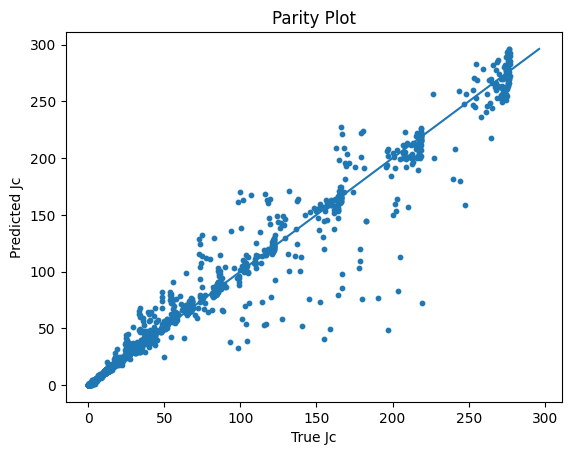

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mlp_predictions.csv")

y_true = df["y_true"]
y_pred = df["y_pred"]

plt.figure()
plt.scatter(y_true, y_pred, s=10)

# y = x 기준선
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True Jc")
plt.ylabel("Predicted Jc")
plt.title("Parity Plot")

plt.show()

In [17]:
df

,Temperature (K),Applied field (T),Applied field angle (°),Critical current (A)
0,19.977,0.0,-5,275.8974
1,19.987,0.0,-2,275.9402
2,19.981,0.0,0,276.0678
3,19.981,0.0,2,276.5573
4,19.994,0.0,5,276.1877
...,...,...,...,...
8767,80.020,8.0,220,0.0012
8768,79.995,8.0,225,0.0027
8769,80.013,8.0,230,0.0093
8770,79.996,8.0,235,0.0353
